### Analista d'experiència del client


Hi ha una relació entre el preu de l'allotjament i la satisfacció general dels clients? Com varia aquesta relació en funció de les diferents ciutats on s'ubiquen els allotjaments?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("../../Data/clean_data_24-03-2026.csv", parse_dates=['insert_date','first_review_date','last_review_date'])

pd.set_option('display.max_columns', 40)

# Selecciono solo las columnas que nos interesan para visualizar más fácil

df[['apartment_id',
    'room_type', 
    'price',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'city']]

,apartment_id,room_type,price,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,city
0,11964,Private room,400.0,78,97.0,100.0,100.0,100.0,100.0,100.0,100.0,75.0,Malaga
1,21853,Private room,170.0,33,92.0,90.0,90.0,100.0,100.0,80.0,90.0,52.0,Madrid
2,32347,Entire home/apt,990.0,148,98.0,100.0,100.0,100.0,100.0,100.0,100.0,142.0,Sevilla
3,35379,Private room,400.0,292,94.0,100.0,90.0,100.0,100.0,100.0,90.0,306.0,Barcelona
4,35801,Private room,900.0,36,97.0,100.0,100.0,100.0,100.0,100.0,100.0,39.0,Girona
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9645,47710189,Entire home/apt,1880.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Girona
9646,47752964,Entire home/apt,1130.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Girona
9647,47792016,Entire home/apt,1150.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Girona
9648,47884481,Entire home/apt,670.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Madrid


Medias generales de las variables de calificación de alojamientos

In [4]:
df[['review_scores_rating', 
    'review_scores_accuracy',
    'review_scores_cleanliness', 
    'review_scores_checkin',
    'review_scores_communication']].mean().round(2)

review_scores_rating           91.91
review_scores_accuracy         94.49
review_scores_cleanliness      93.11
review_scores_checkin          96.23
review_scores_communication    96.21
dtype: float64

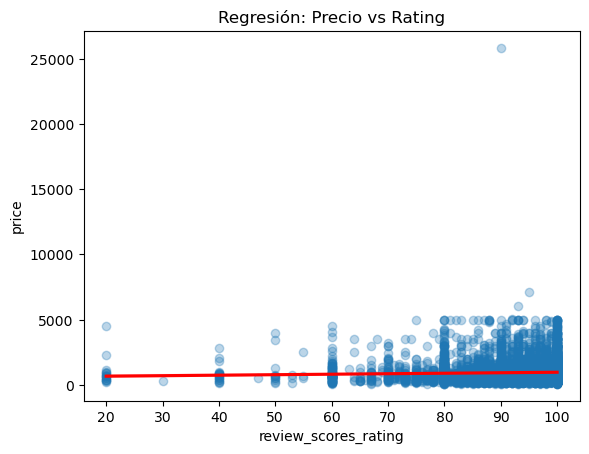

,price,review_scores_rating
price,1.000000,0.041133
review_scores_rating,0.041133,1.000000


In [ ]:
sns.regplot(data=df, x='review_scores_rating', y='price', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Regresión: Precio vs Rating')
plt.show()

df[['price', 'review_scores_rating']].corr()

<Axes: >

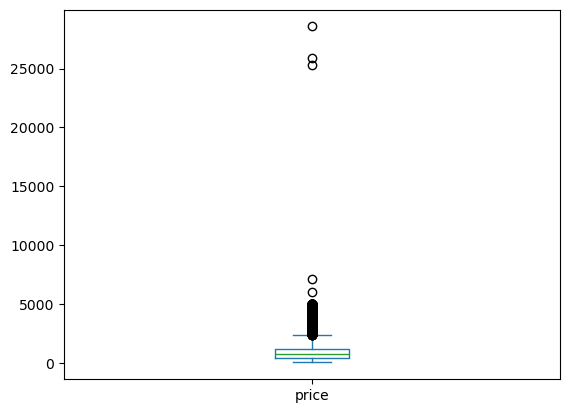

In [8]:
df['price'].plot.box()

In [9]:
df.groupby('city')[['price', 'review_scores_rating']].corr()

price  review_scores_rating
city                                                          
Barcelona price                 1.000000             -0.040943
          review_scores_rating -0.040943              1.000000
Girona    price                 1.000000              0.108110
          review_scores_rating  0.108110              1.000000
Madrid    price                 1.000000              0.033612
          review_scores_rating  0.033612              1.000000
Malaga    price                 1.000000              0.104378
          review_scores_rating  0.104378              1.000000
Mallorca  price                 1.000000              0.079720
          review_scores_rating  0.079720              1.000000
Menorca   price                 1.000000              0.094278
          review_scores_rating  0.094278              1.000000
Sevilla   price                 1.000000              0.011600
          review_scores_rating  0.011600              1.000000
Valencia  price                 1.000000              0.049133
          review_scores_rating  0.049133              1.000000

Hay que analizar también la variable calidad_precio

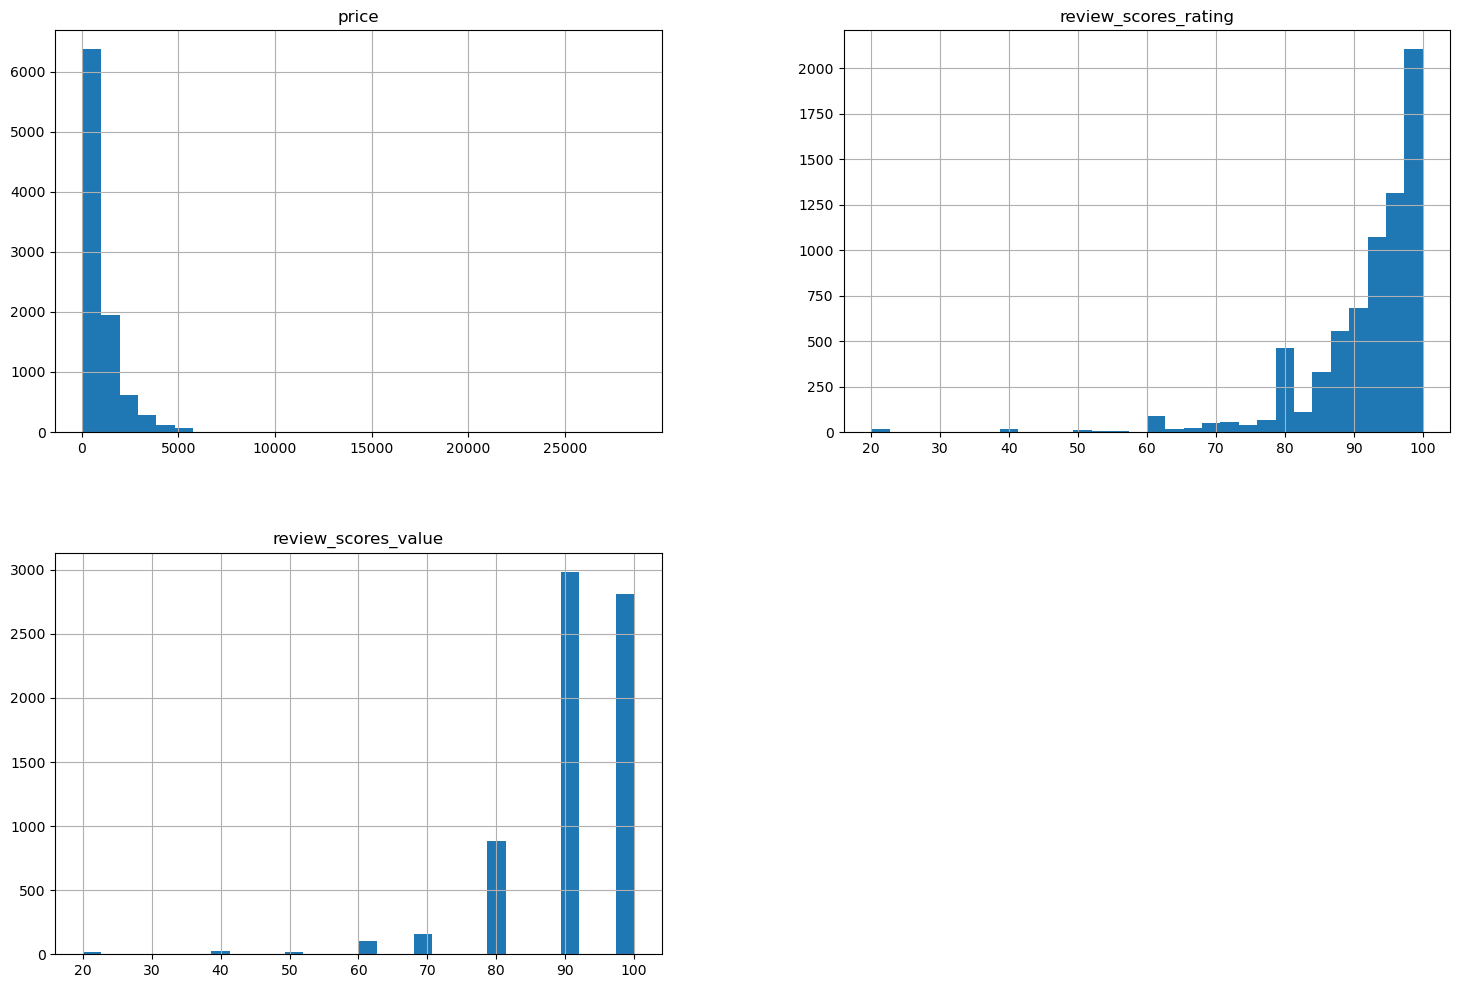

In [11]:
df[['price', 'review_scores_rating', 'review_scores_value']].hist(bins=30, figsize=(18, 12))
plt.show()